#### 로지스틱 회귀
: 선형회귀식을 이용해 회귀라는 단어 있지만 실제적으로 분류에 대한 확률을 계산하는 모델

In [1]:
import pandas as pd

In [2]:
fish = pd.read_csv('../Data/fishes.csv')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [3]:
fish.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB


In [4]:
# Target으로 사용된 Species의 종류
fish.Species.unique()

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str

#### Feature / Target Data 정리

In [6]:
# Feature
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_input[:5]

array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [7]:
# Target
fish_target = fish['Species'].to_numpy()
fish_target[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

#### train과 test 분리

In [8]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_input,
        fish_target,
        random_state=42
    )

#### 표준화
: 각 컬럼별 데이터의 크기 차이가 많이 나는 경우 반드시 처리함

In [10]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [11]:
train_scaled[:5]

array([[ 0.91965782,  0.60943175,  0.81041221,  1.85194896,  1.00075672],
       [ 0.30041219,  1.54653445,  1.45316551, -0.46981663,  0.27291745],
       [-1.0858536 , -1.68646987, -1.70848587, -1.70159849, -2.0044758 ],
       [-0.79734143, -0.60880176, -0.67486907, -0.82480589, -0.27631471],
       [-0.71289885, -0.73062511, -0.70092664, -0.0802298 , -0.7033869 ]])

#### kNN을 이용한 확률 예측

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [13]:
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print("Train :", kn.score(train_scaled, train_target))
print("Test :", kn.score(test_scaled, test_target))

Train : 0.8907563025210085
Test : 0.85


In [14]:
# kn의 분류 정보
kn.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [15]:
# test data로 예측
kn.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch'], dtype=object)

In [16]:
import numpy as np

In [17]:
prob = kn.predict_proba(test_scaled[:5])
np.round(prob, decimals=4)

array([[0.    , 0.    , 1.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 1.    , 0.    ],
       [0.    , 0.    , 0.    , 1.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ]])

> kNN은 이웃의 갯수를 정하는 모델  
> 현재 이웃의 갯수를 3으로 했기 때문에 확률로 나올 수 있는 경우의 수는 3가지 

#### 로지스틱 회귀 이용한 확률 예측  
z = a 무게 + b 길이 + c 대각선 + d 높이 + e 두께 + f로 구성  
z식을 이용하면 나오는 결과값이 - 무한대 ~ + 무한대의 범위로 결과값이 출력됨  
  
이를 해결하는 방법 >> Sigmoid 함수 사용  
    
sigmoid 함수 = 결과값이 0 ~ 1 사이의 수만 출력  
0.5를 기준으로 양성클래스와 음성클래스로 분류
  
로지스틱 회귀를 사용할 경우엔 Sigmoid 함수를 로지스틱함수라고 표현

#### Sigmoid Graph

In [18]:
import matplotlib.pyplot as plt

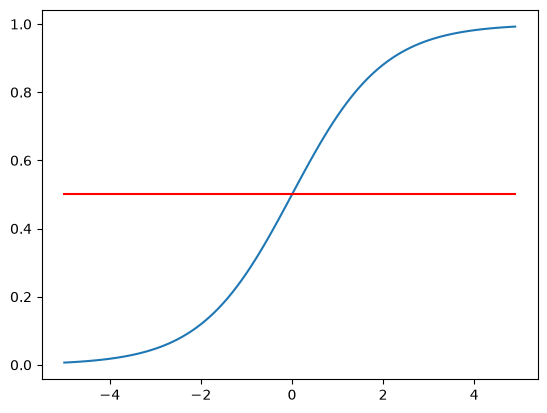

In [22]:
z = np.arange(-5, 5, 0.1)
y = np.full((100, 1), 0.5)
phi = 1 / (1 + np.exp (-z))

plt.plot(z, phi)
plt.plot(z, y, c = 'red')
plt.show()

#### 로지스틱 회귀로 이진분류 수행


In [28]:
import sklearn
sklearn.set_config(display="text")

In [29]:
# 2종류의 데이터만 발췌
bream_smelt_indexes = (train_target == "Bream") | (train_target == "Smelt")
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

print(train_bream_smelt[:5])
print(target_bream_smelt[:5])

[[ 0.91965782  0.60943175  0.81041221  1.85194896  1.00075672]
 [-1.0858536  -1.68646987 -1.70848587 -1.70159849 -2.0044758 ]
 [ 0.63818253  0.56257661  0.73223951  1.64473401  0.50705737]
 [ 0.30041219  0.23459067  0.42823457  1.36042157  0.22329758]
 [ 0.9027693   0.70314202  0.88858491  1.89027545  0.85537174]]
['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [30]:
# 로지스틱 회귀 실행
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

LogisticRegression()

In [31]:
lr.predict_proba(train_bream_smelt[:5])

array([[0.99760007, 0.00239993],
       [0.02737325, 0.97262675],
       [0.99486386, 0.00513614],
       [0.98585047, 0.01414953],
       [0.99767419, 0.00232581]])

#### 로지스틱 회귀로 다중 분류 수행

In [32]:
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.8067226890756303
0.85


In [33]:
lr.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch'], dtype=object)

In [34]:
lr.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [35]:
# 확률 예측
proba = lr.predict_proba(test_scaled[:5])
np.round(proba, decimals=3)

array([[0.004, 0.091, 0.545, 0.008, 0.28 , 0.061, 0.01 ],
       [0.   , 0.061, 0.127, 0.002, 0.087, 0.722, 0.001],
       [0.009, 0.009, 0.223, 0.569, 0.17 , 0.006, 0.013],
       [0.061, 0.077, 0.527, 0.036, 0.257, 0.003, 0.04 ],
       [0.004, 0.03 , 0.664, 0.026, 0.245, 0.018, 0.013]])